# Calculate AQI

## Calculate the AQI from pollutant concentration data

This notebook was generated following the calculation steps given in: https://www.airnow.gov/sites/default/files/2020-05/aqi-technical-assistance-document-sept2018.pdf

This notebook supports AQI calculations for the following pollutants: O$_3$ (ppm) 8-hour, O$_3$ (ppm) 1-hour, PM$_{2.5}$ ($\mu$g/m$^3$) 24-hour, PM$_{10}$ ($\mu$g/m$^3$) 24-hour, CO (ppm) 8-hour, SO$_2$ (ppb) 1-hour, and NO$_2$ (ppb) 1-hour. Note that only the highest concentration among all of the monitors within a given reporting area should be recorded for each pollutant. 

All data should be input as a dictionary with keys as the pollutant (type string) and the values as the concentration (type float). Note that the only accepted keys are the following (corresponding to the above listed pollutants): 'O3_8hr_ppm', 'O3_1hr_ppm', 'PM2.5_24hr_μg/m^3', 'PM10_24hr_μg/m^3', 'CO_8hr_ppm', 'SO2_1hr_ppb', 'NO2_1hr_ppb'.

In [2]:
import math
import numpy as np

### Step 1: Truncate each type of pollutant as follows:
Ozone (ppm) - truncate to 3 decimal places

PM$_{2.5}$ ($\mu$g/m$^3$) - truncate to 1 decimal place

PM$_{10}$ ($\mu$g/m$^3$) - truncate to integer

CO (ppm) - truncate to 1 decimal place

SO$_2$ (ppb) - truncate to integer

NO$_2$ (ppb) - truncate to integer

In [3]:
def truncate_to_three_decimals(number):
    return math.floor(number * 1000) / 1000.0
def truncate_to_one_decimal(number):
    return math.floor(number * 10) / 10.0

In [4]:
def truncation(pollutants,concentrations):
    for i in range(len(pollutants)):
        #ozone case (truncate to 3 decimal places)
        if (pollutants[i] == 'O3_8hr_ppm') or (pollutants[i] == 'O3_1hr_ppm'):
            concentrations[i] = truncate_to_three_decimals(concentrations[i])
        #truncate to 1 decimal place case
        elif (pollutants[i] == 'PM2.5_24hr_μg/m^3') or (pollutants[i] == 'CO_8hr_ppm'):
            concentrations[i] = truncate_to_one_decimal(concentrations[i])
        #truncate to integer
        elif (pollutants[i] == 'PM10_24hr_μg/m^3') or (pollutants[i] == 'SO2_1hr_ppb') or (pollutants[i] == 'NO2_1hr_ppb'):
            concentrations[i] = int(concentrations[i])
        #warn user that one of the keys is not one of the accepted ones
        else:
            print("One of the pollutants entered does not have one of the accepted names! Please ensure that all pollutants are labelled as one of the following: 'O3_8hr_ppm', 'O3_1hr_ppm', 'PM2.5_24hr_μg/m^3', 'PM10_24hr_μg/m^3', 'CO_8hr_ppm', 'SO2_1hr_ppb', 'NO2_1hr_ppb'.")
    return concentrations

### Step 2: Using the table below, find the two breakpoints that contain the concentration and the corresponding AQI range

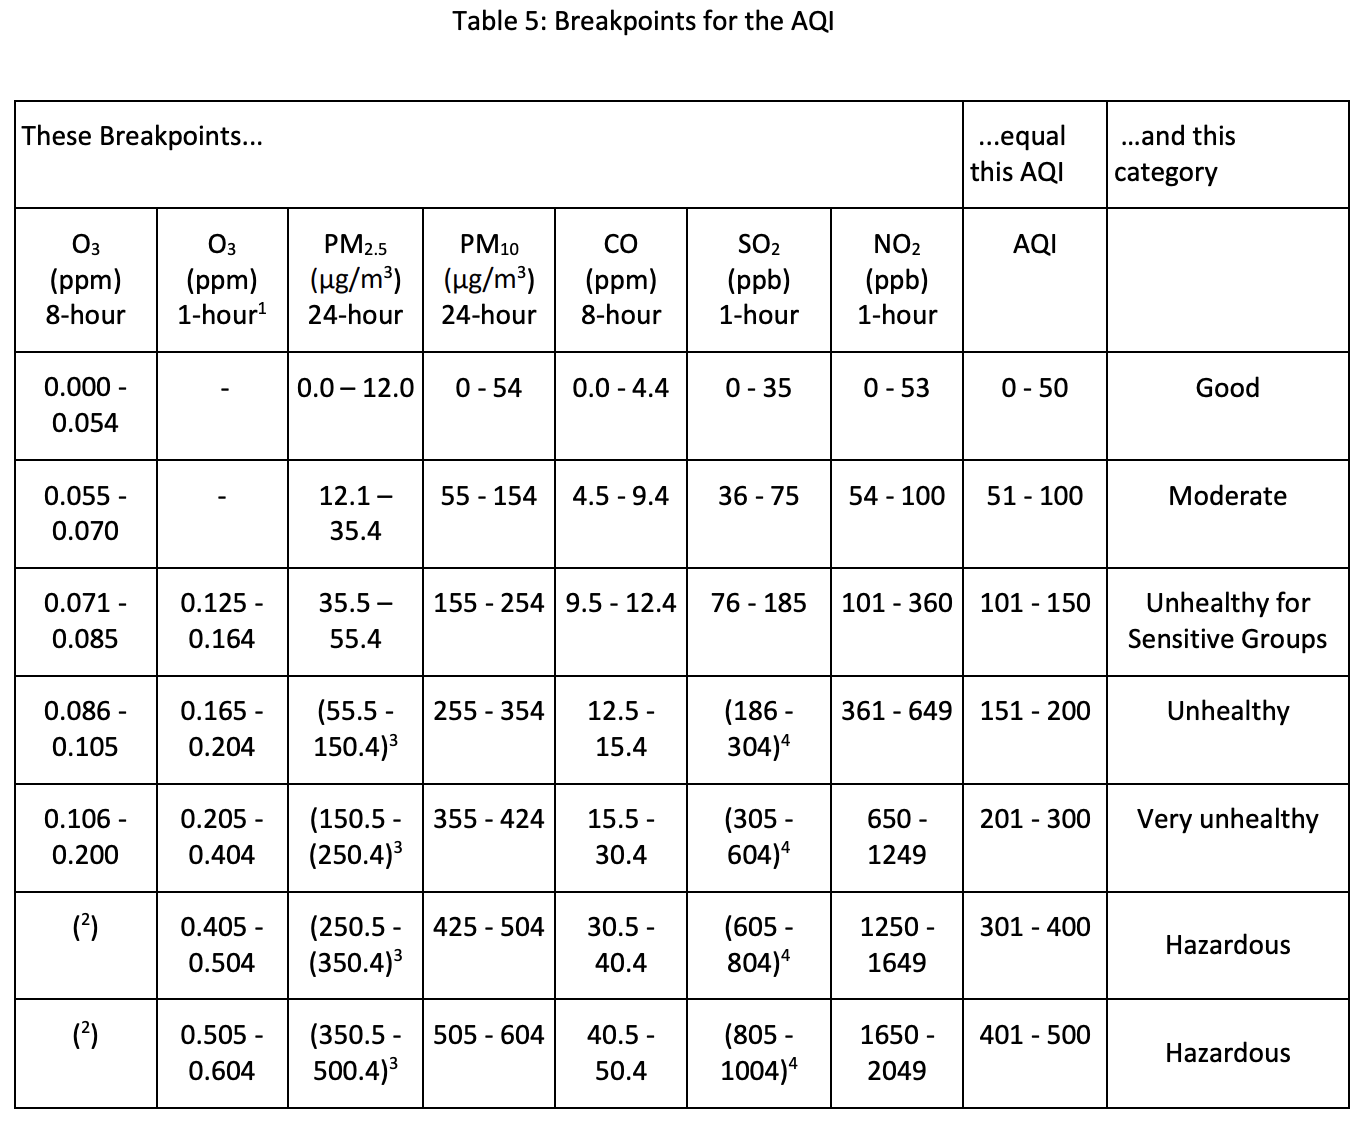

In [12]:
#Dictionary containing breakpoints for the AQI
BP_AQI_ranges = {
    'O3_8hr_ppm': [
        ((0.000, 0.054), (0, 50)),
        ((0.055, 0.070), (51, 100)),
        ((0.071, 0.085), (101, 150)),
        ((0.086, 0.105), (151, 200)),
        ((0.106, 0.200), (201, 300))
    ],
    'O3_1hr_ppm': [
        ((0.000, 0.125), (0, 101)),
        ((0.125, 0.164), (101, 150)),
        ((0.165, 0.204), (151, 200)),
        ((0.205, 0.404), (201, 300)),
        ((0.405, 0.504), (301, 400)),
        ((0.505, 0.604), (401, 500))
    ],
    'PM2.5_24hr_μg/m^3': [
        ((0.0, 12.0), (0, 50)),
        ((12.1, 35.4), (51, 100)),
        ((35.5, 55.4), (101, 150)),
        ((55.5, 150.4), (151, 200)),
        ((150.5, 250.4), (201, 300)),
        ((250.5, 350.4), (301, 400)),
        ((350.5, 500.4), (401, 500))
    ],
    'PM10_24hr_μg/m^3': [
        ((0, 54), (0, 50)),
        ((55, 154), (51, 100)),
        ((155, 254), (101, 150)),
        ((255, 354), (151, 200)),
        ((355, 424), (201, 300)),
        ((425, 504), (301, 400)),
        ((505, 604), (401, 500))
    ],
    'CO_8hr_ppm': [
        ((0.0, 4.4), (0, 50)),
        ((4.5, 9.4), (51, 100)),
        ((9.5, 12.4), (101, 150)),
        ((12.5, 15.4), (151, 200)),
        ((15.5, 30.4), (201, 300)),
        ((30.5, 40.4), (301, 400)),
        ((40.5, 50.4), (401, 500))
    ],
    'SO2_1hr_ppb': [
        ((0, 35), (0, 50)),
        ((36, 75), (51, 100)),
        ((76, 185), (101, 150)),
        ((186, 304), (151, 200)),
        ((305, 604), (201, 300)),
        ((605, 804), (301, 400)),
        ((805, 1004), (401, 500))
    ],
    'NO2_1hr_ppb': [
        ((0, 53), (0, 50)),
        ((54, 100), (51, 100)),
        ((101, 360), (101, 150)),
        ((361, 649), (151, 200)),
        ((650, 1249), (201, 300)),
        ((1250, 1649), (301, 400)),
        ((1650, 2049), (401, 500))
    ]
}

In [6]:
#given the concentration and the given pollutant, return the breakpoints and corresponding AQI range
def find_ranges(concentration, pollutant, BP_AQI_ranges):
    if pollutant in BP_AQI_ranges:
        pollutant_ranges = BP_AQI_ranges[pollutant]
        
        for (BP_lower, BP_upper), (AQI_lower, AQI_upper) in pollutant_ranges:
            if BP_lower <= concentration <= BP_upper:
                return (BP_lower, BP_upper, AQI_lower, AQI_upper)
    
    return None, None, None, None  # If number doesn't fall into any range for the specified category

### Step 3: Calculate the AQI using the following equation: 
$$I_p = \frac{I_{Hi}-I_{Lo}}{BP_{Hi}-BP_{Lo}}(C_p-BP_{Lo})+I_{Lo},$$
where

$I_p$ is the AQI for pollutant $p$

$C_p$ is the truncated concentration of pollutant $p$

$BP_{Hi}$ is the concentration breakpoint that is $\geq C_p$

$BP_{Lo}$ is the concentration breakpoint that is $\leq C_p$

$I_{Hi}$ is the AQI value corresponding to $BP_{Hi}$

$I_{Lo}$ is the AQI value corresponding to $BP_{Lo}.$

### Step 4: Round the AQI to the nearest integer

In [7]:
def AQI(data):
    pollutants = list(data.keys())
    concentrations = list(data.values())
    Ip_vals = np.zeros(len(pollutants))
    #step 1: truncate based on pollutant type
    concentrations = truncation(pollutants,concentrations)
    for i in range(len(pollutants)):
        Cp = concentrations[i]
        #step 2: find the two breakpoints that contain the concentration
        BP_Lo,BP_Hi,I_Lo,I_Hi = find_ranges(Cp,pollutants[i],BP_AQI_ranges)
        if BP_Lo == None:
            print("Given concentration value does not fall within range of known values corresponding to breakpoints.")
        #step 3: calculate the index
        Ip = (((I_Hi - I_Lo) / (BP_Hi - BP_Lo)) * (Cp - BP_Lo)) + I_Lo
        Ip_vals[i] = Ip
    #step 4: round the index to the nearest integer
    AQI_vals = list(map(round, Ip_vals))
    #the AQI is the highest value calculated amongst all pollutants
    AQI = max(AQI_vals)
    AQI_index = AQI_vals.index(AQI)
    print("The AQI is ", AQI, ", with ", pollutants[AQI_index], " as the responsible pollutant.") 
    return AQI

## Test

In [8]:
#test data input as a dictionary
#list only the highest concetration of measured quantity here
data = {'O3_8hr_ppm': 0.0012, 'O3_1hr_ppm': 0.1267, 'PM2.5_24hr_μg/m^3': 0.12, 'PM10_24hr_μg/m^3': 1.1, 'CO_8hr_ppm': 0.12, 'SO2_1hr_ppb': 1.1, 'NO2_1hr_ppb': 1.1}

In [9]:
test_AQI = AQI(data)
print(test_AQI)

The AQI is  102 , with  O3_1hr_ppm  as the responsible pollutant.
102


In [16]:
data2 = {'O3_8hr_ppm': 0.0, 'O3_1hr_ppm': 0.0, 'PM2.5_24hr_μg/m^3': 11.97, 'PM10_24hr_μg/m^3': 24.166667, 'CO_8hr_ppm': 0.343659, 'SO2_1hr_ppb': 0.772414, 'NO2_1hr_ppb': 17.211268}

In [17]:
test_AQI2 = AQI(data2)
print(test_AQI2)

The AQI is  50 , with  PM2.5_24hr_μg/m^3  as the responsible pollutant.
50
